In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('mall_customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
X =df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [8]:
wcss = []
for i in range(2, 9):  
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)

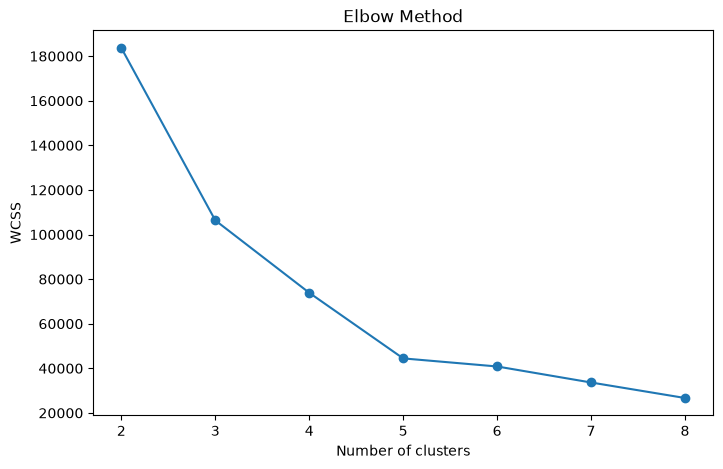

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
model = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_pred = model.fit_predict(X)

In [12]:
df["cluster"] = y_pred


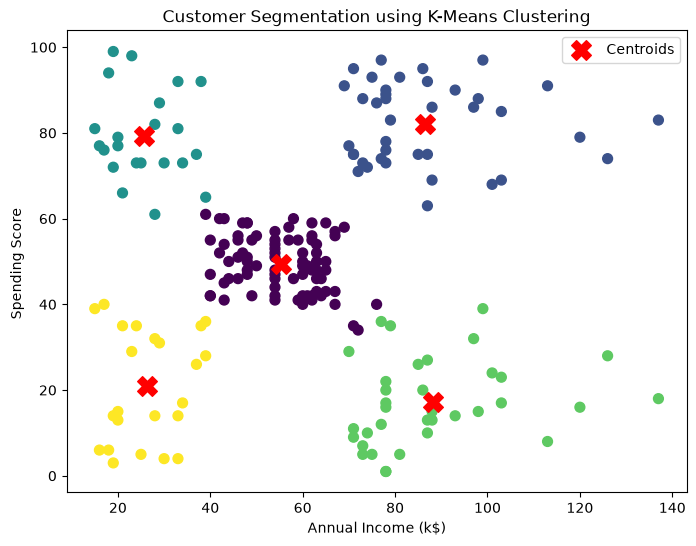

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[: , 0], X.iloc[:, 1], c=y_pred, cmap='viridis', s=50)
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score ')
plt.title('Customer Segmentation using K-Means Clustering')
plt.legend()
plt.show()

In [16]:
print(model.cluster_centers_)                                                                     

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [15]:
labels ={
    0: "budget customers",
    1: "average customers",
    2: "rich but low spending customers",
    3: "low income high spending customers",
    4: "premium customers"
}

df["customer type"] = df["cluster"].map(labels)
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster                    customer type  
0        4                premium customers  
1        2  rich but low spending customers  
2        4                premium customers  
3        2  rich but low spending customers  
4        4                premium customers  
